In [78]:
import pandas as pd

orders = pd.read_csv("../dataset/clean/orders.csv")
reviews = pd.read_csv("../dataset/clean/reviews.csv")
items = pd.read_csv("../dataset/clean/items.csv")
payments = pd.read_csv("../dataset/clean/payments.csv")
products = pd.read_csv("../dataset/clean/products.csv")
category = pd.read_csv("../dataset/clean/category.csv")
customers = pd.read_csv("../dataset/clean/customers.csv")
sellers = pd.read_csv("../dataset/clean/sellers.csv")

In [79]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [80]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.days

In [81]:
reviews['bad_review'] = (
    reviews['review_score'] <= 2
).astype(int)

In [82]:
(reviews['bad_review'].value_counts(normalize=True) * 100).round(2)

bad_review
0    85.31
1    14.69
Name: proportion, dtype: float64

In [83]:
# Reviews + Orders
ml_df = reviews[['order_id', 'bad_review']].merge(
    orders[['order_id', 'customer_id', 'delivery_delay_days']],
    on ='order_id')
# Items + Sellers
ml_df = ml_df.merge(
    items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']],
    on='order_id')
# Payments
ml_df = ml_df.merge(
    payments[['order_id', 'payment_installments', 'payment_value']],
    on='order_id')
# Products
ml_df = ml_df.merge(
    products[['product_id', 'product_category_name']],
    on='product_id')
# Category (English names)
ml_df = ml_df.merge(
    category,
    on='product_category_name',
    how='left')
# Customers
ml_df = ml_df.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id')
# Sellers
ml_df = ml_df.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id')

In [84]:
ml_df.shape

(117329, 14)

In [85]:
ml_df.head()

,order_id,bad_review,customer_id,delivery_delay_days,product_id,seller_id,price,freight_value,payment_installments,payment_value,product_category_name,product_category_name_english,customer_state,seller_state
0,73fc7af87114b39712e6da79b0a377eb,0,41dcb106f807e993532d446263290104,-16.0,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,185.00,13.63,8,397.26,esporte_lazer,sports_leisure,SP,SP
1,73fc7af87114b39712e6da79b0a377eb,0,41dcb106f807e993532d446263290104,-16.0,fd25ab760bfbba13c198fa3b4f1a0cd3,6d803cb79cc31c41c4c789a75933b3c7,185.00,13.63,8,397.26,esporte_lazer,sports_leisure,SP,SP
2,a548910a1c6147796b98fdf73dbeba33,0,8a2e7ef9053dea531e4dc76bd6d853e6,-5.0,be0dbdc3d67d55727a65d4cd696ca73c,8e6d7754bc7e0f22c96d255ebda59eba,79.79,8.30,1,88.09,informatica_acessorios,computers_accessories,SP,SP
3,f9e4b658b201a9f2ecdecbb34bed034b,0,e226dfed6544df5b7b87a48208690feb,-21.0,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,149.00,45.12,1,194.12,informatica_acessorios,computers_accessories,BA,MG
4,658677c97b385a9be170737859d3511b,0,de6dff97e5f1ba84a3cd9a3bc97df5f6,-20.0,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,179.99,42.85,1,222.84,ferramentas_jardim,garden_tools,SC,MG


In [86]:
ml_df.isnull().sum()

order_id                            0
bad_review                          0
customer_id                         0
delivery_delay_days              2471
product_id                          0
seller_id                           0
price                               0
freight_value                       0
payment_installments                0
payment_value                       0
product_category_name               0
product_category_name_english    1720
customer_state                      0
seller_state                        0
dtype: int64

In [87]:
ml_df = ml_df.dropna(subset=['delivery_delay_days'])

In [88]:
ml_df['order_id'].nunique(), len(ml_df)

(95829, 114858)

In [89]:
ml_df.duplicated().sum()

np.int64(11413)

In [90]:
ml_df = ml_df.drop_duplicates()

In [91]:
ml_df.duplicated().sum()

np.int64(0)

In [92]:
ml_df['order_id'].nunique(), len(ml_df)

(95829, 103445)

In [93]:
ml_df['product_category_name_english'] = (
    ml_df['product_category_name_english'].fillna('Unknown'))

In [94]:
ml_df.isnull().sum()

order_id                         0
bad_review                       0
customer_id                      0
delivery_delay_days              0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
payment_installments             0
payment_value                    0
product_category_name            0
product_category_name_english    0
customer_state                   0
seller_state                     0
dtype: int64

In [95]:
ml_df.shape

(103445, 14)

In [96]:
ml_order = (
    ml_df.groupby('order_id')
    .agg({
        'bad_review': 'first',
        'customer_id': 'first',
        'delivery_delay_days': 'first',
        'price': 'sum',
        'freight_value': 'sum',
        'payment_installments': 'max',
        'payment_value': 'sum',
        'product_category_name_english': 'first',
        'customer_state': 'first',
        'seller_state': 'first'
    })
    .reset_index()
)

In [97]:
ml_order.shape

(95829, 11)

In [98]:
ml_order.head

<bound method NDFrame.head of                                order_id  bad_review  \
0      00010242fe8c5a6d1ba2dd792cb16214           0   
1      00018f77f2f0320c557190d7a144bdd3           0   
2      000229ec398224ef6ca0657da4fc703e           0   
3      00024acbcdf0a6daa1e931b038114c75           0   
4      00042b26cf59d7ce69dfabb4e55b4fd9           0   
...                                 ...         ...   
95824  fffc94f6ce00a00581880bf54a75a037           0   
95825  fffcd46ef2263f404302a634eb57f7eb           0   
95826  fffce4705a9662cd70adb13d4a31832d           0   
95827  fffe18544ffabc95dfada21779c9644f           0   
95828  fffe41c64501cc87c801fd61db3f6244           0   

                            customer_id  delivery_delay_days   price  \
0      3ce436f183e68e07877b285a838db11a                 -9.0   58.90   
1      f6dd3ec061db4e3987629fe6b26e5cce                 -3.0  239.90   
2      6489ae5e4333f3693df5ad4372dab6d3                -14.0  199.00   
3      d4eb9395c8c043

In [99]:
ml_df['order_id'].nunique(), len(ml_order)

(95829, 95829)

In [100]:
X = ml_order.drop(
    columns=['order_id', 'bad_review', 'customer_id' ])
y = ml_order['bad_review']

In [101]:
X = pd.get_dummies(
    X,
    columns=['product_category_name_english', 'customer_state', 'seller_state'],
    drop_first=True)

In [102]:
X.shape, y.shape

((95829, 123), (95829,))

In [103]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((76663, 123), (19166, 123))

In [104]:
X_train.shape, X_test.shape

((76663, 123), (19166, 123))

In [105]:
from sklearn.preprocessing import StandardScaler

In [106]:
num_cols = [
    'delivery_delay_days',
    'price',
    'freight_value',
    'payment_installments',
    'payment_value'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [107]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       0.88      0.99      0.94     16712
           1       0.73      0.11      0.19      2454

    accuracy                           0.88     19166
   macro avg       0.81      0.55      0.56     19166
weighted avg       0.86      0.88      0.84     19166

ROC-AUC: 0.6991951695788434


In [108]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     16712
           1       0.66      0.28      0.39      2454

    accuracy                           0.89     19166
   macro avg       0.78      0.63      0.67     19166
weighted avg       0.87      0.89      0.87     19166

ROC-AUC: 0.7256775385133365


In [109]:
from xgboost import XGBClassifier

In [110]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     16712
           1       0.72      0.28      0.40      2454

    accuracy                           0.89     19166
   macro avg       0.81      0.63      0.67     19166
weighted avg       0.88      0.89      0.87     19166

ROC-AUC: 0.7469748908884704


In [111]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values('importance', ascending=False)
    .head(10)
)

feature_importance

,feature,importance
0,delivery_delay_days,0.177536
1,price,0.023436
4,payment_value,0.022087
9,product_category_name_english_audio,0.020190
11,product_category_name_english_baby,0.017635
6,product_category_name_english_air_conditioning,0.017556
12,product_category_name_english_bed_bath_table,0.017531
62,product_category_name_english_office_furniture,0.016162
20,product_category_name_english_computers_access...,0.016142
49,product_category_name_english_home_appliances,0.014747


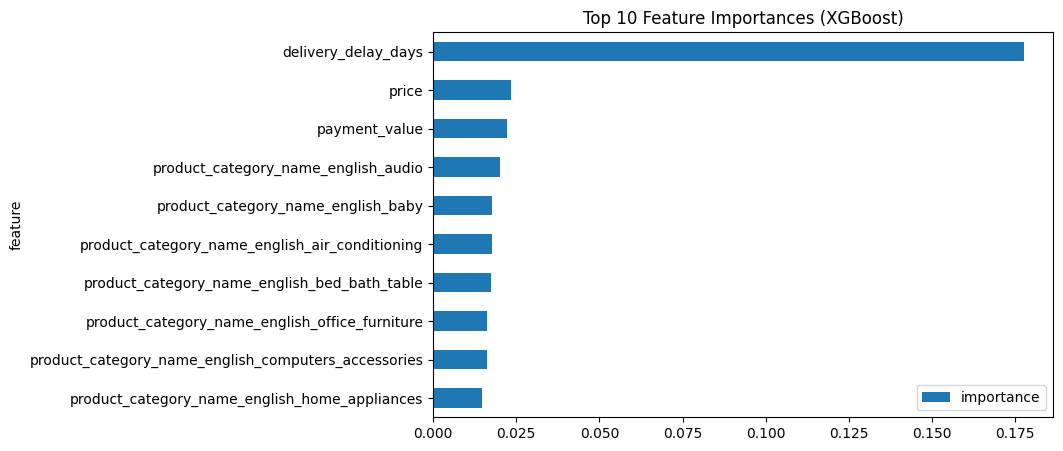

In [112]:
feature_importance.plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,5)
)

plt.title('Top 10 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

In [113]:
import joblib

joblib.dump(xgb, "xgboost_review_predictor.pkl")

['xgboost_review_predictor.pkl']

In [114]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']